# Titanic Survival Analysis

Objective:
Analyze factors affecting passenger survival on the Titanic.

-------------------------------------------------------------------------------------------------------------

## 1. Importing Libraries and Loading Dataset

In this section, we import the required libraries and load the Titanic dataset into a Pandas DataFrame.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
titan = pd.read_csv(r"C:\Users\chand\Downloads\Titanic-Dataset.csv")
titan.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


-------------------------------------------------------------------------------------------------------------

## 2. Initial Data Exploration

This section explores the structure of the dataset, including the number of rows and columns, column names, passenger counts, survival statistics, and basic demographic information.

In [35]:
# Columns in the dataset 
titan.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [36]:
# No of passengers and features
titan.shape

(891, 12)

In [37]:
# How many survived?
s = titan.groupby('Survived').count()
s.head()
s.loc[1] #342
#or
x = titan[titan["Survived"] == 1].shape[0]
x

342

In [38]:
# How many didn't survive?
y = titan[titan["Survived"] != 1].shape[0]
y

549

In [67]:
# What percentage of people survived?
percent = (x/len(titan))*100
percent

38.38383838383838

In [40]:
# Number of male and female passengers

print("Total:",titan.shape[0])
print("Males:", titan[titan['Sex'] == 'male'].shape[0])
print("Females:",titan[titan["Sex"] == 'female'].shape[0])


Total: 891
Males: 577
Females: 314


In [68]:
# Which gender survived more?
print(titan.groupby('Sex')['Survived'].mean().idxmax(),"passengers survived more")

# What is the average age?
print(titan.Age.mean(),"is the average age")

# Who was the oldest passenger?
print(titan['Age'].max(),"is the maximum age")

female passengers survived more
29.36158249158249 is the average age
80.0 is the maximum age


In [42]:
# Which passenger class had the highest survival rate?
print(titan.groupby('Pclass')["Survived"].mean().idxmax(),"class has the highest survival rate")

1 class has the highest survival rate


In [43]:
# Survival rate by gender
titan.groupby('Sex')['Survived'].mean()*100


Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [44]:
# Survival Rate by Passenger Class
titan.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [45]:
#Youngest passenger details
print("Youngest passenger")
print(titan.loc[titan.Age.idxmin()])

#Oldest passenger details
print("\n\nOldest passenger")
print(titan.loc[titan.Age.idxmax()])

Youngest passenger
PassengerId                                804
Survived                                     1
Pclass                                       3
Name           Thomas, Master. Assad Alexander
Sex                                       male
Age                                       0.42
SibSp                                        0
Parch                                        1
Ticket                                    2625
Fare                                    8.5167
Cabin                                      NaN
Embarked                                     C
Name: 803, dtype: object


Oldest passenger
PassengerId                                     631
Survived                                          1
Pclass                                            1
Name           Barkworth, Mr. Algernon Henry Wilson
Sex                                            male
Age                                            80.0
SibSp                                             0
Parch    

In [46]:
# Highest fare passenger
print("Highest fare passenger")
print(titan.loc[titan.Fare.idxmax()])

#Lowest fare passenger
print("\n\nLowest fare passenger")
print(titan.loc[titan.Fare.idxmin()])

Highest fare passenger
PassengerId                 259
Survived                      1
Pclass                        1
Name           Ward, Miss. Anna
Sex                      female
Age                        35.0
SibSp                         0
Parch                         0
Ticket                 PC 17755
Fare                   512.3292
Cabin                       NaN
Embarked                      C
Name: 258, dtype: object


Lowest fare passenger
PassengerId                    180
Survived                         0
Pclass                           3
Name           Leonard, Mr. Lionel
Sex                           male
Age                           36.0
SibSp                            0
Parch                            0
Ticket                        LINE
Fare                           0.0
Cabin                          NaN
Embarked                         S
Name: 179, dtype: object


### Observations:
- Out of all 891 passengers only 342 passengers survived.
- 38.38% is the survival rate of passengers on board.
- Female passengers have a higher survival rate(74.20%) compared to male passengers.
- 1 class passengers have higher survival rate(62.96%) compared to 2 & 3 class passengers.

-------------------------------------------------------------------------------------------------------------

## 3. Missing Value Analysis

Before performing analysis, it is important to identify missing values and understand their impact on the dataset.

In [47]:
# Which columns have missing values?
# How many missing values in each?
a = titan.isnull().sum()
a[a>0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [48]:
# Which column has the highest percentage missing?
b = (titan.isnull().sum()/len(titan))*100
b[b>0].sort_values(ascending=False)

Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64

### Observations:
- Cabin, Age and Embarked columns have missing values.
- Cabin column has the highest percentage(77.10%) of data missing.

-------------------------------------------------------------------------------------------------------------

## 4. Data Cleaning

Missing values are handled in this section to prepare the dataset for further analysis.

In [69]:
# Filling missing values
titan["Age"]=titan["Age"].fillna(value = titan["Age"].median())
titan["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

### Explaination:
The missing values of Age column have been filled with the median of all ages.

-------------------------------------------------------------------------------------------------------------

## 5. Feature Engineering and Survival Analysis

New features are created to improve analysis, including Family_Size and Age_Group.

This section investigates how different factors such as gender, passenger class, age group, and family size influence survival rates.

In [63]:
# Adding a new column for determining child or adult
titan['Age_Group']=np.where(titan["Age"]>18,'Adult','Child')
titan.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,0
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q,Adult,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Adult,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Child,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Adult,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Child,1


In [50]:
# Finding survival rate of children and adults
titan.groupby("Age_Group")['Survived'].mean()*100

Age_Group
Adult    36.170213
Child    50.359712
Name: Survived, dtype: float64

In [51]:
# Top 10 passengers with highest fare
a = titan.Fare.sort_values(ascending=False).head(10)
print(a)

# Top 10 passengers with highest fare who survived
b = titan[titan['Survived'] == 1].sort_values(by="Fare",ascending=False).head(10)[["PassengerId","Pclass"]]
print(b)

679    512.3292
258    512.3292
737    512.3292
88     263.0000
438    263.0000
341    263.0000
27     263.0000
742    262.3750
311    262.3750
299    247.5208
Name: Fare, dtype: float64
     PassengerId  Pclass
679          680       1
737          738       1
258          259       1
88            89       1
341          342       1
742          743       1
311          312       1
299          300       1
716          717       1
380          381       1


In [52]:
# Average fare of survivors
print(titan[titan["Survived"]==1].Fare.mean(),"is the average fare of survivors")

# Average fare of survivors
print(titan[titan["Survived"] == 0].Fare.mean(),"is the average fare of non-survivors")

# Did paying more improve survival chances?
print("Yes paying more increased survival rate.")

48.39540760233918 is the average fare of survivors
22.117886885245902 is the average fare of non-survivors
Yes paying more increased survival rate.


In [53]:
# Passenger with constraints
titan[(titan.Sex == 'female') & (titan.Survived == 1) & (titan.Age_Group == 'Child') & (titan.Pclass == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C,Child
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,Child
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C,Child
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S,Child
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5000,B79,S,Child
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6500,E68,S,Child
689,690,1,1,"Madill, Miss. Georgette Alexandra",female,15.0,0,1,24160,211.3375,B5,S,Child
700,701,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C,Child
781,782,1,1,"Dick, Mrs. Albert Adrian (Vera Gillespie)",female,17.0,1,0,17474,57.0000,B20,S,Child
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S,Child


In [54]:
# Which class has most passengers and least passengers
titan.groupby("Pclass")["PassengerId"].count().sort_values(ascending=False)

Pclass
3    491
1    216
2    184
Name: PassengerId, dtype: int64

In [ ]:
# Top survivors by fare
titan[titan["Survived"] == 1].sort_values(by="Fare",ascending=False).head(10)[["Name","Fare","Age","Pclass"]]

,Name,Fare,Age,Pclass
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,36.0,1
737,"Lesurer, Mr. Gustave J",512.3292,35.0,1
258,"Ward, Miss. Anna",512.3292,35.0,1
88,"Fortune, Miss. Mabel Helen",263.0000,23.0,1
341,"Fortune, Miss. Alice Elizabeth",263.0000,24.0,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",262.3750,21.0,1
311,"Ryerson, Miss. Emily Borie",262.3750,18.0,1
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",247.5208,50.0,1
716,"Endres, Miss. Caroline Louise",227.5250,38.0,1
380,"Bidois, Miss. Rosalie",227.5250,42.0,1


In [57]:
# Calculating the family size
titan["family_size"] = titan["SibSp"]+titan["Parch"]
titan["family_size"]

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: family_size, Length: 891, dtype: int64

In [58]:
# Largest family size?
print(titan["family_size"].max(),"is the max family size")

# Average family size?
print(titan["family_size"].mean(),"is the average family size")

# Did people with families survive more?
alone = titan[titan["family_size"]==0]["Survived"].mean()*100
family = titan[titan["family_size"]>0]["Survived"].mean()*100
print(alone,"is the survival rate of solo travellers")
print(family,"is the survival rate of family travellers")

10 is the max family size
0.9046015712682379 is the average family size
30.353817504655495 is the survival rate of solo travellers
50.56497175141242 is the survival rate of family travellers


In [59]:
# More specific age groups
titan["Age_Group"]=pd.cut(titan["Age"],bins=[0,18,35,60,100],labels=["Child","Young","Middle","Senior"])
titan["Age_Group"]

0       Young
1      Middle
2       Young
3       Young
4       Young
        ...  
886     Young
887     Young
888     Young
889     Young
890     Young
Name: Age_Group, Length: 891, dtype: category
Categories (4, str): ['Child' < 'Young' < 'Middle' < 'Senior']

In [60]:
# Counting people in each age group
titan.groupby("Age_Group")["PassengerId"].count()

Age_Group
Child     139
Young     535
Middle    195
Senior     22
Name: PassengerId, dtype: int64

In [61]:
# Survival rate of each group
titan.groupby("Age_Group")["Survived"].mean()*100

Age_Group
Child     50.359712
Young     35.327103
Middle    40.000000
Senior    22.727273
Name: Survived, dtype: float64

In [62]:
# Group that has maximum survival rate
titan.groupby("Age_Group")["Survived"].mean().idxmax()

'Child'

### Observations:
- Paying more fare increased the survival rate.
- Most of the passengers(491) belonged to 3 class.
- 50.56 is the survival rate of passengers with families.
- 30.35 is the survival rate of solo travellers.
- Most of the passengers belonged to the age group of 18-35 years.
- The survival rate of children is maximum.(50.35%)


-------------------------------------------------------------------------------------------------------------

## 6. Data Visualization

Visualizations are created to better understand patterns and trends in the Titanic dataset.

<Axes: xlabel='Pclass'>

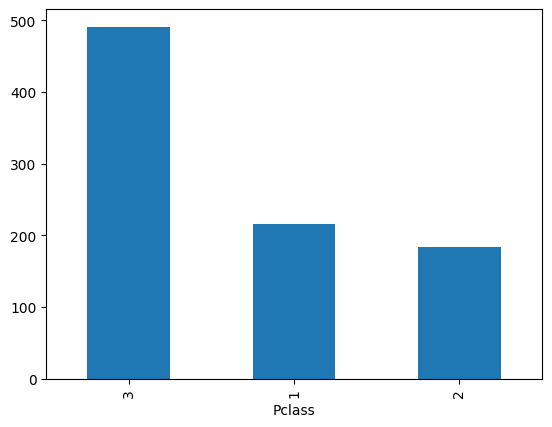

In [66]:
# Visualization
titan["Pclass"].value_counts().plot(kind="bar")

### Observations:
- There are more 3rd class passengers followed by 1st class passengers and then 2nd class passengers. 

-------------------------------------------------------------------------------------------------------------

## 8. Key Findings

The analysis revealed several important patterns:

- Female passengers had a higher survival rate than males.
- First-class passengers survived more frequently than passengers in lower classes.
- Passengers travelling with family are more likely to survive.
- Children and middle age passengers are more likely to survive.

-------------------------------------------------------------------------------------------------------------

## Conclusion

The analysis indicates that gender, passenger class, family size and age were the strongest factors affecting survival on the Titanic. Female passengers travelling in first class had the highest probability of survival followed by children belonging to any class.

This project demonstrated data cleaning, feature engineering, exploratory data analysis, and visualization using Pandas and Matplotlib.